In [69]:
!pip install pandas matplotlib seaborn numpy

In [70]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Use seaborn to set up template for plotting
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.titlesize': 18
})

In [71]:
#Load the dataset, and provide basic statistics - no_pb_valid
csv_path = 'results/posebusters_filtered_evaluation.csv'

df = pd.read_csv(csv_path)
print(f"Successfully loaded dataset with {len(df)} entries.")

# Convert the RMSD column to numeric, turning errors/strings into NaN.
# errors=coerce is to allow the script to keep moving forward after assigning NaN - default is errors='raise', which would've crashed the program
rmsd_col = 'rmsd' if 'rmsd' in df.columns else df.columns[1]
df['clean_rmsd'] = pd.to_numeric(df[rmsd_col], errors='coerce')

# Performance metrics
total_complexes = len(df)
substructure_failures = df['clean_rmsd'].isna().sum()
valid_complexes = total_complexes - substructure_failures

succ_2A = (df['clean_rmsd'] < 2.0).sum()
succ_1A = (df['clean_rmsd'] < 1.0).sum()
median_rmsd = df['clean_rmsd'].median()

print("\n--- Summary Metrics ---")
print(f"Total Complexes Evaluated: {total_complexes}")
print(f"Substructure Mismatches / Empty Rows: {substructure_failures} ({substructure_failures/total_complexes*100:.1f}%)")
print(f"Valid RMSD Calculations: {valid_complexes}")
print(f"Median RMSD (Valid data): {median_rmsd:.2f} Å")
print(f"Success Rate (< 2.0 Å): {succ_2A / total_complexes * 100:.1f}% of total")
print(f"High Quality (< 1.0 Å): {succ_1A / total_complexes * 100:.1f}% of total")


Successfully loaded dataset with 308 entries.

--- Summary Metrics ---
Total Complexes Evaluated: 308
Substructure Mismatches / Empty Rows: 69 (22.4%)
Valid RMSD Calculations: 239
Median RMSD (Valid data): 0.34 Å
Success Rate (< 2.0 Å): 73.7% of total
High Quality (< 1.0 Å): 66.9% of total


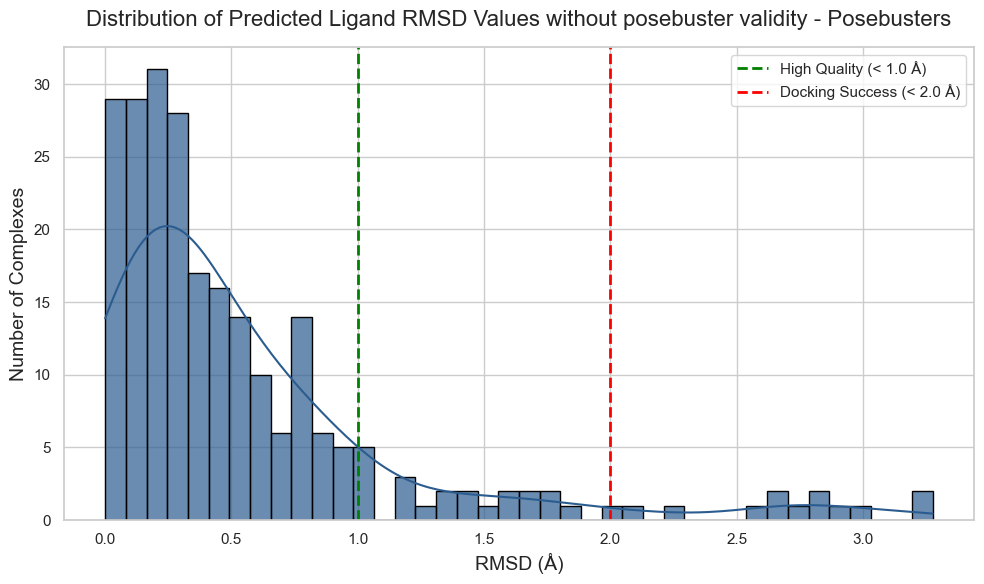

In [72]:
# RMSD Distribution (Histogram + KDE) for posebusters filtered
plt.figure(figsize=(10, 6))

# Filter out NaNs for the distribution plot
valid_rmsd_data = df['clean_rmsd'].dropna()

# Plot histogram with a smooth density curve (KDE - Kernel Density Estimation)
# KDE cont. - used to estimate the Probability Density Function(PDF) 
sns.histplot(valid_rmsd_data, kde=True, bins=40, color='#2b5c8f', edgecolor='black', alpha=0.7)

# Reference lines for docking thresholds
plt.axvline(x=1.0, color='green', linestyle='--', linewidth=2, label='High Quality (< 1.0 Å)')
plt.axvline(x=2.0, color='red', linestyle='--', linewidth=2, label='Docking Success (< 2.0 Å)')

plt.title('Distribution of Predicted Ligand RMSD Values without posebuster validity - Posebusters', pad=15)
plt.xlabel('RMSD (Å)')
plt.ylabel('Number of Complexes')
plt.legend()
plt.tight_layout()
plt.savefig('results/rmsd_distribution.png', dpi=300)
plt.show()

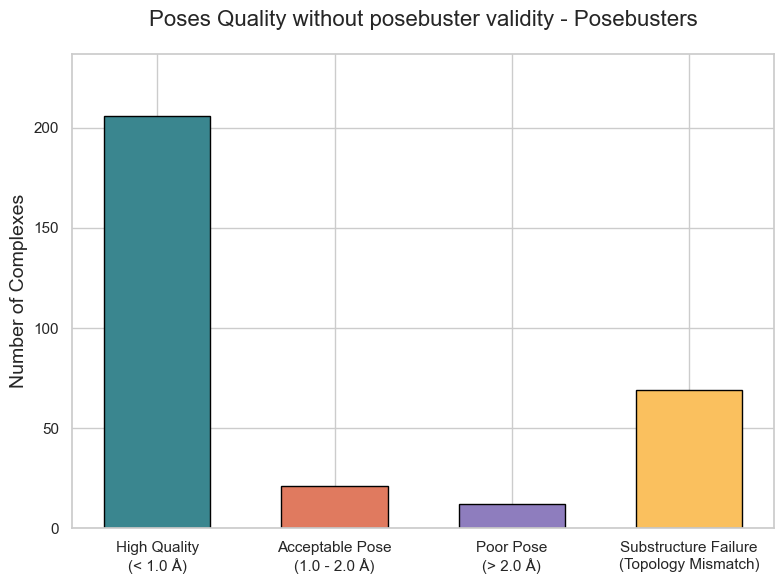

In [73]:
# Performance of the docking pipeline
plt.figure(figsize=(8, 6))
categories = []
for val in df['clean_rmsd']:
    if pd.isna(val):
        categories.append('Substructure Failure\n(Topology Mismatch)')
    elif val < 1.0:
        categories.append('High Quality\n(< 1.0 Å)')
    elif val < 2.0:
        categories.append('Acceptable Pose\n(1.0 - 2.0 Å)')
    else:
        categories.append('Poor Pose\n(> 2.0 Å)')

df['Performance_Category'] = categories
category_counts = df['Performance_Category'].value_counts()

# Order the categories logically for the chart
plot_order = [
    'High Quality\n(< 1.0 Å)', 
    'Acceptable Pose\n(1.0 - 2.0 Å)', 
    'Poor Pose\n(> 2.0 Å)', 
    'Substructure Failure\n(Topology Mismatch)'
]
category_counts = category_counts.reindex(plot_order).fillna(0)

# Generate a bar chart
palette=["#3A868F", "#E07A5F", "#8E7DBE", "#FAC05E"]
bars = plt.bar(category_counts.index, category_counts.values, color=palette , edgecolor='black', width=0.6)

plt.title('Poses Quality without posebuster validity - Posebusters', pad=20)
plt.ylabel('Number of Complexes')
plt.ylim(0, max(category_counts.values) * 1.15) 
plt.savefig('results/pose_quality.png', dpi=300)
plt.tight_layout()
plt.show()

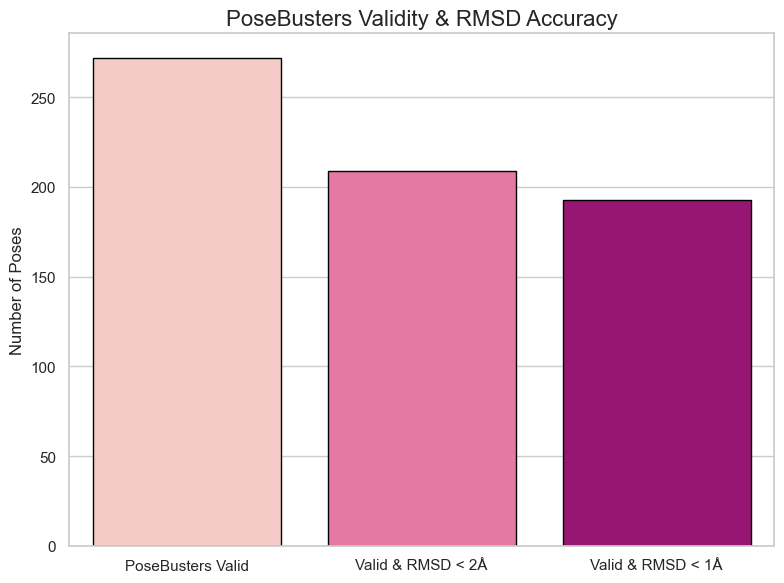

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the evaluation dataset - posebuster valid
df = pd.read_csv("results/my_eval_pb.csv")

# Calculate the exact filtered counts
total_pb_valid = df['pb_valid'].sum()

# Filter for rows where pb_valid is True, then count RMSD thresholds
valid_df = df[df['pb_valid'] == True]
valid_lt2 = valid_df['rmsd_lt2'].sum()
valid_lt1 = valid_df['rmsd_lt1'].sum()

plot_data = pd.DataFrame({
    'Metric': ['PoseBusters Valid', 'Valid & RMSD < 2Å', 'Valid & RMSD < 1Å'],
    'Count': [total_pb_valid, valid_lt2, valid_lt1]
})

plt.figure(figsize=(8, 6))

# Bar plot
ax = sns.barplot(data=plot_data, x='Metric', y='Count', hue='Metric', palette="RdPu", edgecolor='black')
plt.title('PoseBusters Validity & RMSD Accuracy')
plt.xlabel('', fontsize=12)
plt.ylabel('Number of Poses', fontsize=12)
plt.savefig('results/posebuster_valid_pb.png', dpi=300)
plt.tight_layout()
plt.show()